#Numerical implications in audio watermarking
Nicholas Brogle, Diana Kohr, Mataio Nonaka

1. base implementation of watermarking, embedding, extraction, and imperceptibility and robustness measures
2. run base implementation on different setups:
- different

In [ ]:
# signal-to-noise ratio: imperceptibility
def snr(original, watermarked):
    return 10 * np.log10(np.sum(original**2) / np.sum((original - watermarked)**2))

# normalized correlation: robustness
def nc(original, extracted):
    return np.sum(original * extracted) / (np.linalg.norm(original) * np.linalg.norm(extracted))

# bit error rate: robustness
def ber(original, extracted):
    return np.sum(np.abs(original - extracted)) / len(original)

### Attacks

In [ ]:
# Additive white Gaussian noise (AWGN): White Gaussian noise is added to the watermarked signal until the resulting signal has an SNR of 20 dB.
def awgn(signal):
    noise = np.random.normal(0, 1, signal.shape)
    while snr(signal, signal + 0.01 * noise) > 20:
        noise += np.random.normal(0, 1, signal.shape)
    return signal + 0.01 * noise

# Resampling: The watermarked signal, originally sampled at 44.1 kHz, is resampled at 22.05 kHz, and then restored back by sampling again at 44.1 kHz.
def resampling(signal):
    return librosa.resample(librosa.resample(signal, orig_sr=44100, target_sr=22050), orig_sr=22050, target_sr=44100)

# Low-pass filtering: A second-order Butterworth filter with cut-off frequency 11,025 Hz is used.
def lpf(signal):
    b, a = sp.signal.butter(
        N=2,
        Wn=11025/(44100/2),
        btype='low',
        analog=False,
        output='ba'
    )
    return sp.signal.filtfilt(b, a, signal)

In [ ]:
import numpy as np
import pywt
from scipy.io import wavfile
import librosa
import matplotlib.pyplot as plt


def embedding(P, A, watermark, signalinframe, iter, dwtlevel):
   cnt = 1
   ind = 0

   # Gain vector
   if np.isscalar(P):
       gain = P * np.ones(iter)
   else:
       gain = np.array(P)


   U11 = []
   V11 = []
   watermarked_frames = []


   for ii in range(iter):
       frame = A[cnt - 1 : signalinframe * (ii + 1)]
       temp = frame.copy()


       # Multi-level DWT
       cA = {}
       cD = {}
       for jj in range(1, dwtlevel + 1):
           cA[jj], cD[jj] = pywt.dwt(temp, 'haar')
           temp = cD[jj]


       # vectorform = [cA_end', flipud(cat(cD))']
       temp_vec = cD[1]
       for jj in range(1, dwtlevel):
           temp_vec = np.concatenate([temp_vec, cD[jj+1]])
       vectorform = np.concatenate([cA[dwtlevel].T, np.flipud(temp_vec).T])


       # === Construct matrix D (figure 6 logic) ===
       D = cD[1].T[None, :]


       for jj in range(1, dwtlevel):
           rep = np.tile(cD[jj+1].T, (1, 2**jj))
           D = np.vstack([D, rep[:, :D.shape[1]]])


       # === SVD of D ===
       U, S_diag, Vt = np.linalg.svd(D, full_matrices=False)
       S = np.diag(S_diag)


       # === Construct W matrix ===
       W = np.zeros((dwtlevel, dwtlevel))
       cnt1 = 1


       for kk in range(dwtlevel**2 - 1):
           if (kk + 1) == (cnt1 + dwtlevel + 1):
               W.flat[kk + 1] = 0
               counter = True
           else:
               W.flat[kk + 1] = watermark[ind]
               ind += 1


           if 'counter' in locals():
               cnt1 += dwtlevel + 1
               del counter


       # Add watermark
       Sw = S + gain[ii] * W


       # SVD of modified S
       U1, S1_diag, V1t = np.linalg.svd(Sw, full_matrices=False)
       S1 = np.diag(S1_diag)


       U11.append(U1.reshape(-1))
       V11.append(V1t.reshape(-1))


       # Reconstruct modified D
       Dww = U @ S1 @ Vt


       # === Inverse DWT reconstruction ===
       colms = Dww.shape[1]
       Dww_cD = {}


       for kk in range(1, dwtlevel + 1):
           if kk == 1 or kk == 2:
               Dww_cD[kk] = Dww[kk - 1, : colms // kk]
           else:
               Dww_cD[kk] = Dww[kk - 1, : colms // (2 ** (kk - 1))]


       temp = Dww_cD[dwtlevel]


       for jj in range(dwtlevel, 0, -1):
           cA_j = cA[jj]


           if len(cA_j) > len(temp):
               dim = len(cA_j) - len(temp)
               temp = np.pad(temp, (0, dim))
           elif len(cA_j) < len(temp):
               temp = temp[:len(cA_j)]


           temp = pywt.idwt(cA_j, temp, 'haar')


       watermarked_frames.append(temp)
       cnt = signalinframe * (ii + 1) + 1


   # Concatenate final watermarked signal
   finalwatermarked = np.concatenate(watermarked_frames)


   return finalwatermarked, np.array(U11), np.array(V11)


P = 0.1                 # gain
signalinframe = 64      # samples per frame
iter = 3                # number of frames
dwtlevel = 3            # DWT depth


# --- Input signal A ---
# Create a simple test signal: e.g., a sine wave + noise
N = signalinframe * iter
t = np.linspace(0, 1, N)
A = 0.8*np.sin(2*np.pi*5*t) + 0.05*np.random.randn(N)


# --- Watermark bits ---
# Need enough bits for W matrix + S modification
# Rough safe choice:
watermark_length = (dwtlevel**2) * iter
watermark = np.random.randint(0, 2, watermark_length)


# --- Run embedding ---
finalwatermarked, U11, V11 = embedding(
   P=P,
   A=A,
   watermark=watermark,
   signalinframe=signalinframe,
   iter=iter,
   dwtlevel=dwtlevel
)


print("finalwatermarked length:", len(finalwatermarked))
print("U11 shape:", U11.shape)
print("V11 shape:", V11.shape)
print("Example output (first 10 samples):", finalwatermarked[:10])

filename = "/sos.mp3"


A, sr = librosa.load(filename, sr=None)


dwtlevel = 3
signalinframe = 2048
iter = 350  # fits inside 769536 samples
P = 0.05 * np.ones(iter)


A = A[:signalinframe * iter]


num_bits_needed_per_frame = dwtlevel**2 - 1
watermark = np.random.randint(0, 2, iter * num_bits_needed_per_frame)




# Now call your function
finalwatermarked, U11, V11 = embedding(
   P=P,
   A=A,
   watermark=watermark,
   signalinframe=signalinframe,
   iter=iter,
   dwtlevel=dwtlevel
)




diff = finalwatermarked - A


# Option 1: Plot difference directly
plt.figure(figsize=(12, 4))
plt.plot(diff[:5000])  # first 5000 samples
plt.title("Difference between Watermarked and Original Signal")
plt.xlabel("Sample index")
plt.ylabel("Amplitude difference")
plt.show()


snr = 10 * np.log10(np.sum(A**2) / np.sum((A - finalwatermarked)**2))
print("SNR (dB):", snr)


finalwatermarked length: 192
U11 shape: (3, 9)
V11 shape: (3, 9)
Example output (first 10 samples): [-0.19527975  0.12913104  0.22153904  0.38115324  0.46655764  0.61734917
  0.72184753  0.73897089  0.82045347  0.77404585]


/tmp/ipython-input-2560833835.py:173: UserWarning: PySoundFile failed. Trying audioread instead.
  A, sr = librosa.load(filename, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: '/sos.mp3'

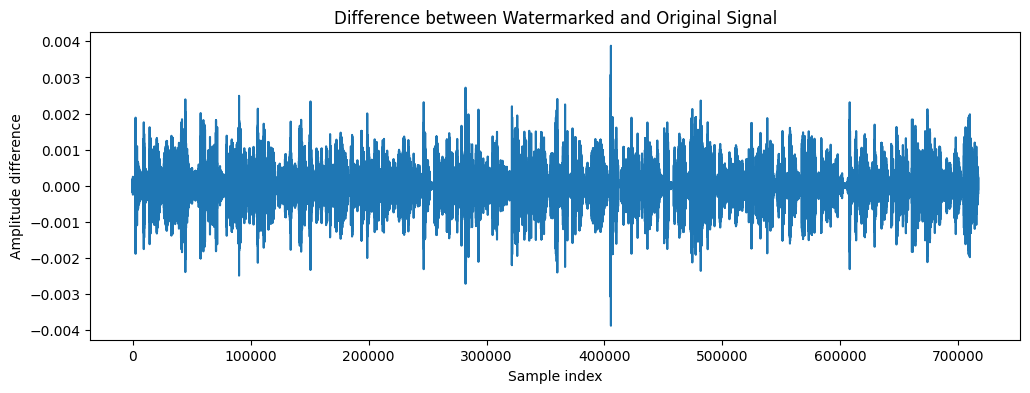

SNR (dB): 48.2080810083319


In [ ]:
filename = "/content/sample-15s.mp3"


A, sr = librosa.load(filename, sr=None)


dwtlevel = 3
signalinframe = 2048
iter = 350  # fits inside 769536 samples
P = 0.05 * np.ones(iter)


A = A[:signalinframe * iter]


num_bits_needed_per_frame = dwtlevel**2 - 1
watermark = np.random.randint(0, 2, iter * num_bits_needed_per_frame)




# Now call your function
finalwatermarked, U11, V11 = embedding(
   P=P,
   A=A,
   watermark=watermark,
   signalinframe=signalinframe,
   iter=iter,
   dwtlevel=dwtlevel
)




diff = finalwatermarked - A


# Option 1: Plot difference directly
plt.figure(figsize=(12, 4))
plt.plot(diff)  # first 5000 samples
plt.title("Difference between Watermarked and Original Signal")
plt.xlabel("Sample index")
plt.ylabel("Amplitude difference")
plt.show()


snr = 10 * np.log10(np.sum(A**2) / np.sum((A - finalwatermarked)**2))
print("SNR (dB):", snr)


In [ ]:
import numpy as np
import pywt
import librosa
import soundfile as sf
import scipy as sp
import matplotlib.pyplot as plt
from scipy.fft import dct, idct
import time

# ---------------------------
# PARAMETERS
# ---------------------------
dwtlevel = 4
signalinframe = 4096
iter = 175
alpha = 0.15
redundancy = 3

# ---------------------------
# UTILITY FUNCTIONS
# ---------------------------
def add_redundancy(bits, redundancy=3):
    return np.repeat(bits, redundancy)

def majority_decode(bits, redundancy=3):
    bits = np.array(bits)
    decoded = []
    for i in range(0, len(bits), redundancy):
        chunk = bits[i:i+redundancy]
        decoded.append(1 if np.sum(chunk) > redundancy/2 else 0)
    return np.array(decoded)

def snr(signal, noisy_signal):
    noise = signal - noisy_signal
    signal_power = np.sum(signal**2)
    noise_power = np.sum(noise**2)
    if noise_power == 0:
        return np.inf
    return 10 * np.log10(signal_power / noise_power)

def awgn(signal, target_snr=20):
    signal_power = np.mean(signal**2)
    target_noise_power = signal_power / (10**(target_snr/10))
    noise_std = np.sqrt(target_noise_power)
    noise = np.random.normal(0, noise_std, signal.shape)
    return signal + noise

def resampling(signal, orig_sr=44100):
    down = librosa.resample(signal, orig_sr=orig_sr, target_sr=22050)
    up = librosa.resample(down, orig_sr=22050, target_sr=orig_sr)
    if len(up) > len(signal):
        up = up[:len(signal)]
    elif len(up) < len(signal):
        up = np.pad(up, (0, len(signal) - len(up)), mode='constant')
    return up

def lpf(signal, sr=44100):
    b, a = sp.signal.butter(N=2, Wn=11025/(sr/2), btype='low', analog=False, output='ba')
    return sp.signal.filtfilt(b, a, signal)

# ---------------------------
# SCHEME 1: DWT-SVD-ROBUST (Your Method)
# ---------------------------
class DWT_SVD_Robust:
    def __init__(self, alpha=0.15, redundancy=3):
        self.alpha = alpha
        self.redundancy = redundancy
        self.bits_list = []

    def embed(self, A, watermark, signalinframe, iter, dwtlevel):
        watermark_redundant = add_redundancy(watermark, self.redundancy)
        ind = 0
        watermarked_frames = []
        self.bits_list = []

        for ii in range(iter):
            if ind >= len(watermark_redundant):
                watermarked_frames.append(A[ii*signalinframe:(ii+1)*signalinframe].copy())
                self.bits_list.append(0)
                continue

            frame = A[ii*signalinframe:(ii+1)*signalinframe].copy()
            coeffs = pywt.wavedec(frame, 'db4', level=dwtlevel)
            cA = coeffs[0]
            cD1 = coeffs[1]
            combined = np.concatenate([cA, cD1])

            n = len(combined)
            rows = int(np.sqrt(n))
            cols = n // rows
            matrix_size = rows * cols

            if matrix_size < 16:
                watermarked_frames.append(frame)
                self.bits_list.append(0)
                continue

            matrix = combined[:matrix_size].reshape(rows, cols)
            U, S, Vt = np.linalg.svd(matrix, full_matrices=False)

            num_bits_frame = min(5, min(len(S), len(watermark_redundant)-ind))
            bits_count = 0

            for k in range(num_bits_frame):
                bit = watermark_redundant[ind]
                if bit == 1:
                    S[k] = S[k] * (1 + self.alpha)
                else:
                    S[k] = S[k] * (1 - self.alpha)
                ind += 1
                bits_count += 1

            self.bits_list.append(bits_count)

            matrix_mod = U @ np.diag(S) @ Vt
            combined_mod = matrix_mod.flatten()
            combined_full = combined.copy()
            combined_full[:matrix_size] = combined_mod

            cA_mod = combined_full[:len(cA)]
            cD1_mod = combined_full[len(cA):len(cA)+len(cD1)]
            coeffs[0] = cA_mod
            coeffs[1] = cD1_mod

            frame_mod = pywt.waverec(coeffs, 'db4')
            if len(frame_mod) > signalinframe:
                frame_mod = frame_mod[:signalinframe]
            elif len(frame_mod) < signalinframe:
                frame_mod = np.pad(frame_mod, (0, signalinframe - len(frame_mod)), mode='edge')

            watermarked_frames.append(frame_mod)

        return np.concatenate(watermarked_frames)

    def extract(self, A_w, A_orig, signalinframe, iter, dwtlevel):
        extracted_bits = []

        for ii in range(iter):
            if self.bits_list[ii] == 0:
                continue

            frame_w = A_w[ii*signalinframe:(ii+1)*signalinframe].copy()
            frame_orig = A_orig[ii*signalinframe:(ii+1)*signalinframe].copy()

            coeffs_w = pywt.wavedec(frame_w, 'db4', level=dwtlevel)
            coeffs_orig = pywt.wavedec(frame_orig, 'db4', level=dwtlevel)

            combined_w = np.concatenate([coeffs_w[0], coeffs_w[1]])
            combined_orig = np.concatenate([coeffs_orig[0], coeffs_orig[1]])

            n = len(combined_w)
            rows = int(np.sqrt(n))
            cols = n // rows
            matrix_size = rows * cols

            if matrix_size == 0:
                continue

            matrix_w = combined_w[:matrix_size].reshape(rows, cols)
            matrix_orig = combined_orig[:matrix_size].reshape(rows, cols)

            _, S_w, _ = np.linalg.svd(matrix_w, full_matrices=False)
            _, S_orig, _ = np.linalg.svd(matrix_orig, full_matrices=False)

            for k in range(self.bits_list[ii]):
                ratio = S_w[k] / (S_orig[k] + 1e-10)
                extracted_bits.append(1 if ratio > 1.0 else 0)

        return majority_decode(np.array(extracted_bits), self.redundancy)

# ---------------------------
# SCHEME 2: DWT-SVD-QIM
# ---------------------------
class DWT_SVD_QIM:
    def __init__(self, delta=5.0):
        self.delta = delta
        self.n_bits = 0

    def embed(self, A, watermark, signalinframe, iter):
        n_frames = len(A) // signalinframe
        watermarked = A.copy()
        bit_idx = 0

        for i in range(n_frames):
            if bit_idx >= len(watermark):
                break
            frame = A[i*signalinframe:(i+1)*signalinframe]
            coeffs = pywt.wavedec(frame, 'db4', level=3)
            cA = coeffs[0]

            n = len(cA)
            rows = int(np.sqrt(n))
            cols = n // rows
            matrix = cA[:rows*cols].reshape(rows, cols)
            U, S, Vt = np.linalg.svd(matrix, full_matrices=False)

            if bit_idx < len(watermark):
                bit = watermark[bit_idx]
                q = np.round(S[0] / self.delta)
                S[0] = self.delta * (q + (0.25 if bit == 0 else 0.75))
                bit_idx += 1

            matrix_mod = U @ np.diag(S) @ Vt
            cA[:rows*cols] = matrix_mod.flatten()
            coeffs[0] = cA
            frame_mod = pywt.waverec(coeffs, 'db4')
            watermarked[i*signalinframe:(i+1)*signalinframe] = frame_mod[:signalinframe]

        self.n_bits = bit_idx
        return watermarked

    def extract(self, A_w, signalinframe):
        n_frames = len(A_w) // signalinframe
        extracted = []

        for i in range(min(n_frames, self.n_bits)):
            frame_w = A_w[i*signalinframe:(i+1)*signalinframe]
            coeffs_w = pywt.wavedec(frame_w, 'db4', level=3)

            n = len(coeffs_w[0])
            rows = int(np.sqrt(n))
            cols = n // rows
            matrix_w = coeffs_w[0][:rows*cols].reshape(rows, cols)
            _, S_w, _ = np.linalg.svd(matrix_w, full_matrices=False)

            s = S_w[0]
            remainder = s % self.delta
            normalized_pos = remainder / self.delta
            extracted.append(1 if normalized_pos > 0.5 else 0)

        return np.array(extracted)

# ---------------------------
# SCHEME 3: LSB
# ---------------------------
class LSB:
    def __init__(self):
        self.n_bits = 0

    def embed(self, signal, watermark):
        watermarked = signal.copy()
        signal_int = (signal * 32767).astype(np.int16)

        for i, bit in enumerate(watermark):
            if i >= len(signal_int):
                break
            signal_int[i] = (signal_int[i] & ~1) | bit

        self.n_bits = min(len(watermark), len(signal_int))
        return signal_int.astype(np.float32) / 32767

    def extract(self, watermarked):
        signal_int = (watermarked * 32767).astype(np.int16)
        return np.array([s & 1 for s in signal_int[:self.n_bits]])

# ---------------------------
# SCHEME 4: DCT-Based
# ---------------------------
class DCT_Based:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.n_bits = 0

    def embed(self, signal, watermark, frame_size=4096):
        n_frames = len(signal) // frame_size
        watermarked = signal.copy()
        bit_idx = 0

        for i in range(n_frames):
            if bit_idx >= len(watermark):
                break
            frame = signal[i*frame_size:(i+1)*frame_size]
            dct_coeffs = dct(frame, norm='ortho')

            if bit_idx < len(watermark):
                bit = watermark[bit_idx]
                mid_freq = frame_size // 4
                if bit == 1:
                    dct_coeffs[mid_freq] += self.alpha * abs(dct_coeffs[mid_freq])
                else:
                    dct_coeffs[mid_freq] -= self.alpha * abs(dct_coeffs[mid_freq])
                bit_idx += 1

            frame_mod = idct(dct_coeffs, norm='ortho')
            watermarked[i*frame_size:(i+1)*frame_size] = frame_mod

        self.n_bits = bit_idx
        return watermarked

    def extract(self, watermarked, original, frame_size=4096):
        n_frames = len(watermarked) // frame_size
        extracted = []

        for i in range(min(n_frames, self.n_bits)):
            frame_w = watermarked[i*frame_size:(i+1)*frame_size]
            frame_o = original[i*frame_size:(i+1)*frame_size]

            dct_w = dct(frame_w, norm='ortho')
            dct_o = dct(frame_o, norm='ortho')

            mid_freq = frame_size // 4
            extracted.append(1 if dct_w[mid_freq] > dct_o[mid_freq] else 0)

        return np.array(extracted)

# ---------------------------
# SCHEME 5: DWT-Only
# ---------------------------
class DWT_Only:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.n_bits = 0

    def embed(self, signal, watermark, frame_size=4096):
        n_frames = len(signal) // frame_size
        watermarked = signal.copy()
        bit_idx = 0

        for i in range(n_frames):
            if bit_idx >= len(watermark):
                break
            frame = signal[i*frame_size:(i+1)*frame_size]
            coeffs = pywt.wavedec(frame, 'db4', level=3)

            if bit_idx < len(watermark):
                bit = watermark[bit_idx]
                if bit == 1:
                    coeffs[0][0] += self.alpha * abs(coeffs[0][0])
                else:
                    coeffs[0][0] -= self.alpha * abs(coeffs[0][0])
                bit_idx += 1

            frame_mod = pywt.waverec(coeffs, 'db4')
            watermarked[i*frame_size:(i+1)*frame_size] = frame_mod[:frame_size]

        self.n_bits = bit_idx
        return watermarked

    def extract(self, watermarked, original, frame_size=4096):
        n_frames = len(watermarked) // frame_size
        extracted = []

        for i in range(min(n_frames, self.n_bits)):
            frame_w = watermarked[i*frame_size:(i+1)*frame_size]
            frame_o = original[i*frame_size:(i+1)*frame_size]

            coeffs_w = pywt.wavedec(frame_w, 'db4', level=3)
            coeffs_o = pywt.wavedec(frame_o, 'db4', level=3)

            extracted.append(1 if coeffs_w[0][0] > coeffs_o[0][0] else 0)

        return np.array(extracted)

# ---------------------------
# SCHEME 6: Spread Spectrum
# ---------------------------
class SpreadSpectrum:
    def __init__(self, alpha=0.01):
        self.alpha = alpha
        self.pn_sequence = None
        self.n_bits = 0

    def embed(self, signal, watermark, frame_size=4096):
        np.random.seed(42)
        watermarked = signal.copy()
        self.pn_sequence = np.random.randn(len(signal))

        for i, bit in enumerate(watermark):
            if i * frame_size >= len(signal):
                break
            start = i * frame_size
            end = min(start + frame_size, len(signal))
            if bit == 1:
                watermarked[start:end] += self.alpha * self.pn_sequence[start:end]
            else:
                watermarked[start:end] -= self.alpha * self.pn_sequence[start:end]

        self.n_bits = min(len(watermark), len(signal) // frame_size)
        return watermarked

    def extract(self, watermarked, original, frame_size=4096):
        extracted = []
        for i in range(self.n_bits):
            if i * frame_size >= len(watermarked):
                break
            start = i * frame_size
            end = min(start + frame_size, len(watermarked))
            diff = watermarked[start:end] - original[start:end]
            correlation = np.sum(diff * self.pn_sequence[start:end])
            extracted.append(1 if correlation > 0 else 0)

        return np.array(extracted)

# ---------------------------
# COMPREHENSIVE TESTING
# ---------------------------
def comprehensive_robustness_test():
    print("="*70)
    print("COMPREHENSIVE ROBUSTNESS TESTING - ALL SCHEMES")
    print("="*70)

    # Load audio
    print("\nLoading audio file...")
    filename = "/content/_016_shop.mp3"
    A, sr = librosa.load(filename, sr=None)
    A = A[:signalinframe*iter]

    print(f"Audio: {len(A)/sr:.2f}s, {sr}Hz")

    # Generate watermark
    watermark_len = 100
    np.random.seed(42)
    watermark = np.random.randint(0, 2, watermark_len)

    # Initialize schemes
    schemes = {
        'DWT-SVD-Robust': DWT_SVD_Robust(alpha=0.15, redundancy=3),
        'DWT-SVD-QIM': DWT_SVD_QIM(delta=5.0),
        'LSB': LSB(),
        'DCT-Based': DCT_Based(alpha=0.1),
        'DWT-Only': DWT_Only(alpha=0.1),
        'Spread Spectrum': SpreadSpectrum(alpha=0.01)
    }

    # Embed watermarks
    print("\nEmbedding watermarks...")
    watermarked_signals = {}

    for name, scheme in schemes.items():
        print(f"  - {name}...", end=" ")
        if name == 'DWT-SVD-Robust':
            watermarked = scheme.embed(A, watermark, signalinframe, iter, dwtlevel)
        elif name == 'DWT-SVD-QIM':
            watermarked = scheme.embed(A, watermark, signalinframe, iter)
        elif name == 'LSB':
            watermarked = scheme.embed(A, watermark)
        else:
            watermarked = scheme.embed(A, watermark, signalinframe)
        watermarked_signals[name] = watermarked
        print("✓")

    # Define attacks
    attacks = {
        'No Attack': lambda x: x,
        'AWGN (20dB)': lambda x: awgn(x, 20),
        'Resampling': lambda x: resampling(x, sr),
        'Low-pass Filter': lambda x: lpf(x, sr)
    }

    # Test all combinations
    results = []

    print("\n" + "="*70)
    print("TESTING ALL SCHEME-ATTACK COMBINATIONS")
    print("="*70)

    for scheme_name, scheme in schemes.items():
        print(f"\n{scheme_name}:")
        for attack_name, attack_func in attacks.items():
            # Apply attack
            attacked = attack_func(watermarked_signals[scheme_name].copy())

            # Extract watermark
            if scheme_name == 'DWT-SVD-Robust':
                extracted = scheme.extract(attacked, A, signalinframe, iter, dwtlevel)
            elif scheme_name == 'DWT-SVD-QIM':
                extracted = scheme.extract(attacked, signalinframe)
            elif scheme_name == 'LSB':
                extracted = scheme.extract(attacked)
            elif scheme_name in ['DCT-Based', 'DWT-Only', 'Spread Spectrum']:
                extracted = scheme.extract(attacked, A, signalinframe)
            else:
                extracted = scheme.extract(attacked, A, signalinframe)

            # Calculate metrics
            min_len = min(len(extracted), len(watermark))
            ber = np.mean(extracted[:min_len] != watermark[:min_len])
            nc = np.corrcoef(extracted[:min_len], watermark[:min_len])[0, 1] if ber < 0.5 else 0
            attack_snr = snr(watermarked_signals[scheme_name], attacked)

            print(f"  {attack_name:<20} BER: {ber:.4f}, NC: {nc:.4f}, SNR: {attack_snr:.2f}dB")

            results.append({
                'Scheme': scheme_name,
                'Attack': attack_name,
                'BER': ber,
                'NC': nc,
                'SNR': attack_snr,
                'Accuracy': (1-ber)*100
            })

    # Generate visualizations
    create_robustness_plots(results)

    return results

def create_robustness_plots(results):
    """Create comprehensive visualization of robustness results"""

    import pandas as pd
    df = pd.DataFrame(results)

    schemes = df['Scheme'].unique()
    attacks = df['Attack'].unique()

    fig = plt.figure(figsize=(20, 12))

    # Plot 1: BER Heatmap
    ax1 = plt.subplot(2, 3, 1)
    ber_matrix = df.pivot(index='Scheme', columns='Attack', values='BER')
    im1 = ax1.imshow(ber_matrix.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.5)
    ax1.set_xticks(range(len(attacks)))
    ax1.set_yticks(range(len(schemes)))
    ax1.set_xticklabels(attacks, rotation=45, ha='right')
    ax1.set_yticklabels(schemes)
    ax1.set_title('Bit Error Rate (BER) - Lower is Better', fontweight='bold')

    # Add text annotations
    for i in range(len(schemes)):
        for j in range(len(attacks)):
            text = ax1.text(j, i, f'{ber_matrix.values[i, j]:.3f}',
                          ha="center", va="center", color="black", fontsize=8)

    plt.colorbar(im1, ax=ax1, label='BER')

    # Plot 2: NC Heatmap
    ax2 = plt.subplot(2, 3, 2)
    nc_matrix = df.pivot(index='Scheme', columns='Attack', values='NC')
    im2 = ax2.imshow(nc_matrix.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax2.set_xticks(range(len(attacks)))
    ax2.set_yticks(range(len(schemes)))
    ax2.set_xticklabels(attacks, rotation=45, ha='right')
    ax2.set_yticklabels(schemes)
    ax2.set_title('Normalized Correlation (NC) - Higher is Better', fontweight='bold')

    for i in range(len(schemes)):
        for j in range(len(attacks)):
            text = ax2.text(j, i, f'{nc_matrix.values[i, j]:.3f}',
                          ha="center", va="center", color="black", fontsize=8)

    plt.colorbar(im2, ax=ax2, label='NC')

    # Plot 3: Accuracy by Attack
    ax3 = plt.subplot(2, 3, 3)
    for attack in attacks:
        attack_data = df[df['Attack'] == attack]
        ax3.plot(attack_data['Scheme'], attack_data['Accuracy'],
                marker='o', label=attack, linewidth=2)
    ax3.set_xlabel('Scheme')
    ax3.set_ylabel('Accuracy (%)')
    ax3.set_title('Accuracy Comparison by Attack', fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)
    ax3.set_xticklabels(schemes, rotation=45, ha='right')

    # Plot 4: BER by Scheme
    ax4 = plt.subplot(2, 3, 4)
    x = np.arange(len(schemes))
    width = 0.2
    for i, attack in enumerate(attacks):
        attack_data = df[df['Attack'] == attack]
        ax4.bar(x + i*width, attack_data['BER'], width, label=attack)
    ax4.set_xlabel('Scheme')
    ax4.set_ylabel('BER')
    ax4.set_title('BER Comparison (Lower is Better)', fontweight='bold')
    ax4.set_xticks(x + width * 1.5)
    ax4.set_xticklabels(schemes, rotation=45, ha='right')
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)

    # Plot 5: Robustness Score (1-BER averaged across attacks)
    ax5 = plt.subplot(2, 3, 5)
    robustness_scores = []
    for scheme in schemes:
        scheme_data = df[df['Scheme'] == scheme]
        avg_ber = scheme_data['BER'].mean()
        robustness_scores.append((1 - avg_ber) * 100)

    colors = plt.cm.viridis(np.linspace(0, 1, len(schemes)))
    bars = ax5.barh(schemes, robustness_scores, color=colors)
    ax5.set_xlabel('Average Robustness Score (%)')
    ax5.set_title('Overall Robustness Ranking', fontweight='bold')
    ax5.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, (bar, score) in enumerate(zip(bars, robustness_scores)):
        ax5.text(score + 1, i, f'{score:.1f}%', va='center')

    # Plot 6: Attack Severity Analysis
    ax6 = plt.subplot(2, 3, 6)
    attack_severity = []
    for attack in attacks:
        attack_data = df[df['Attack'] == attack]
        avg_ber = attack_data['BER'].mean()
        attack_severity.append(avg_ber)

    colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(attacks)))
    bars = ax6.bar(attacks, attack_severity, color=colors)
    ax6.set_ylabel('Average BER')
    ax6.set_title('Attack Severity (Higher = More Damaging)', fontweight='bold')
    ax6.set_xticklabels(attacks, rotation=45, ha='right')
    ax6.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, severity in zip(bars, attack_severity):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{severity:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('/content/robustness_analysis_all_schemes.png', dpi=300, bbox_inches='tight')
    print("\n📊 Comprehensive plots saved as 'robustness_analysis_all_schemes.png'")
    plt.show()

    # Create summary table
    print("\n" + "="*90)
    print("ROBUSTNESS SUMMARY TABLE")
    print("="*90)
    print(f"{'Scheme':<20} {'No Attack':<15} {'AWGN':<15} {'Resampling':<15} {'LPF':<15}")
    print("-"*90)
    for scheme in schemes:
        row = [scheme]
        for attack in attacks:
            data = df[(df['Scheme'] == scheme) & (df['Attack'] == attack)]
            ber = data['BER'].values[0]
            row.append(f"{ber:.4f}")
        print(f"{row[0]:<20} {row[1]:<15} {row[2]:<15} {row[3]:<15} {row[4]:<15}")

    print("\n" + "="*90)
    print("BEST PERFORMERS")
    print("="*90)

    for attack in attacks:
        attack_data = df[df['Attack'] == attack]
        best = attack_data.loc[attack_data['BER'].idxmin()]
        print(f"{attack:<20} → {best['Scheme']} (BER: {best['BER']:.4f}, NC: {best['NC']:.4f})")

# Run comprehensive test
if __name__ == "__main__":
    results = comprehensive_robustness_test()

In [ ]:
import numpy as np
import pywt
import librosa
import soundfile as sf
import scipy as sp
import time
import matplotlib.pyplot as plt
from scipy.fft import dct, idct

# ---------------------------
# SCHEME 1: DWT-SVD (Your Current Method)
# ---------------------------
def dwt_svd_embed(signal, watermark, frame_size=4096, alpha=0.08):
    """DWT-SVD watermarking"""
    start_time = time.time()

    n_frames = len(signal) // frame_size
    watermarked = signal.copy()
    bit_idx = 0

    for i in range(n_frames):
        if bit_idx >= len(watermark):
            break

        frame = signal[i*frame_size:(i+1)*frame_size]

        # DWT
        coeffs = pywt.wavedec(frame, 'db4', level=3)
        cA = coeffs[0]

        # SVD
        n = len(cA)
        rows = int(np.sqrt(n))
        cols = n // rows
        matrix = cA[:rows*cols].reshape(rows, cols)
        U, S, Vt = np.linalg.svd(matrix, full_matrices=False)

        # Embed bit
        if bit_idx < len(watermark):
            bit = watermark[bit_idx]
            S[0] = S[0] * (1 + alpha if bit == 1 else 1 - alpha)
            bit_idx += 1

        # Reconstruct
        matrix_mod = U @ np.diag(S) @ Vt
        cA[:rows*cols] = matrix_mod.flatten()
        coeffs[0] = cA
        frame_mod = pywt.waverec(coeffs, 'db4')

        watermarked[i*frame_size:(i+1)*frame_size] = frame_mod[:frame_size]

    embed_time = time.time() - start_time

    # Extraction
    start_time = time.time()
    extracted = []
    for i in range(n_frames):
        if i >= len(watermark):
            break
        frame_w = watermarked[i*frame_size:(i+1)*frame_size]
        frame_o = signal[i*frame_size:(i+1)*frame_size]

        coeffs_w = pywt.wavedec(frame_w, 'db4', level=3)
        coeffs_o = pywt.wavedec(frame_o, 'db4', level=3)

        n = len(coeffs_w[0])
        rows = int(np.sqrt(n))
        cols = n // rows

        matrix_w = coeffs_w[0][:rows*cols].reshape(rows, cols)
        matrix_o = coeffs_o[0][:rows*cols].reshape(rows, cols)

        _, S_w, _ = np.linalg.svd(matrix_w, full_matrices=False)
        _, S_o, _ = np.linalg.svd(matrix_o, full_matrices=False)

        extracted.append(1 if S_w[0] > S_o[0] else 0)

    extract_time = time.time() - start_time

    return watermarked, np.array(extracted), embed_time, extract_time

# ---------------------------
# SCHEME 2: DWT-SVD-QIM
# ---------------------------
def dwt_svd_qim_embed(signal, watermark, frame_size=4096, delta=5.0):
    """DWT-SVD with QIM (Quantization Index Modulation)"""
    start_time = time.time()

    n_frames = len(signal) // frame_size
    watermarked = signal.copy()
    bit_idx = 0

    for i in range(n_frames):
        if bit_idx >= len(watermark):
            break

        frame = signal[i*frame_size:(i+1)*frame_size]

        # DWT
        coeffs = pywt.wavedec(frame, 'db4', level=3)
        cA = coeffs[0]

        # SVD
        n = len(cA)
        rows = int(np.sqrt(n))
        cols = n // rows
        matrix = cA[:rows*cols].reshape(rows, cols)
        U, S, Vt = np.linalg.svd(matrix, full_matrices=False)

        # QIM Embedding
        if bit_idx < len(watermark):
            bit = watermark[bit_idx]
            s_orig = S[0]
            # Quantize to nearest delta multiple
            q = np.round(s_orig / delta)
            # Place at 0.25 or 0.75 position based on bit
            if bit == 0:
                S[0] = delta * (q + 0.25)
            else:
                S[0] = delta * (q + 0.75)
            bit_idx += 1

        # Reconstruct
        matrix_mod = U @ np.diag(S) @ Vt
        cA[:rows*cols] = matrix_mod.flatten()
        coeffs[0] = cA
        frame_mod = pywt.waverec(coeffs, 'db4')

        watermarked[i*frame_size:(i+1)*frame_size] = frame_mod[:frame_size]

    embed_time = time.time() - start_time

    # Extraction (blind - doesn't need original)
    start_time = time.time()
    extracted = []
    for i in range(n_frames):
        if i >= len(watermark):
            break
        frame_w = watermarked[i*frame_size:(i+1)*frame_size]

        coeffs_w = pywt.wavedec(frame_w, 'db4', level=3)

        n = len(coeffs_w[0])
        rows = int(np.sqrt(n))
        cols = n // rows

        matrix_w = coeffs_w[0][:rows*cols].reshape(rows, cols)

        _, S_w, _ = np.linalg.svd(matrix_w, full_matrices=False)

        # QIM Extraction
        s = S_w[0]
        remainder = s % delta
        normalized_pos = remainder / delta

        # Decision: closer to 0.25 or 0.75?
        extracted.append(1 if normalized_pos > 0.5 else 0)

    extract_time = time.time() - start_time

    return watermarked, np.array(extracted), embed_time, extract_time

# ---------------------------
# SCHEME 3: LSB (Least Significant Bit)
# ---------------------------
def lsb_embed(signal, watermark, frame_size=4096):
    """Simple LSB watermarking"""
    start_time = time.time()

    watermarked = signal.copy()
    signal_int = (signal * 32767).astype(np.int16)

    for i, bit in enumerate(watermark):
        if i >= len(signal_int):
            break
        signal_int[i] = (signal_int[i] & ~1) | bit

    watermarked = signal_int.astype(np.float32) / 32767
    embed_time = time.time() - start_time

    # Extraction
    start_time = time.time()
    signal_int = (watermarked * 32767).astype(np.int16)
    extracted = np.array([s & 1 for s in signal_int[:len(watermark)]])
    extract_time = time.time() - start_time

    return watermarked, extracted, embed_time, extract_time

# ---------------------------
# SCHEME 4: DCT-Based
# ---------------------------
def dct_embed(signal, watermark, frame_size=4096, alpha=0.1):
    """DCT-based watermarking"""
    start_time = time.time()

    n_frames = len(signal) // frame_size
    watermarked = signal.copy()
    bit_idx = 0

    for i in range(n_frames):
        if bit_idx >= len(watermark):
            break

        frame = signal[i*frame_size:(i+1)*frame_size]
        dct_coeffs = dct(frame, norm='ortho')

        if bit_idx < len(watermark):
            bit = watermark[bit_idx]
            mid_freq = frame_size // 4
            if bit == 1:
                dct_coeffs[mid_freq] += alpha * abs(dct_coeffs[mid_freq])
            else:
                dct_coeffs[mid_freq] -= alpha * abs(dct_coeffs[mid_freq])
            bit_idx += 1

        frame_mod = idct(dct_coeffs, norm='ortho')
        watermarked[i*frame_size:(i+1)*frame_size] = frame_mod

    embed_time = time.time() - start_time

    # Extraction
    start_time = time.time()
    extracted = []
    for i in range(n_frames):
        if i >= len(watermark):
            break
        frame_w = watermarked[i*frame_size:(i+1)*frame_size]
        frame_o = signal[i*frame_size:(i+1)*frame_size]

        dct_w = dct(frame_w, norm='ortho')
        dct_o = dct(frame_o, norm='ortho')

        mid_freq = frame_size // 4
        extracted.append(1 if dct_w[mid_freq] > dct_o[mid_freq] else 0)

    extract_time = time.time() - start_time

    return watermarked, np.array(extracted), embed_time, extract_time

# ---------------------------
# SCHEME 5: DWT-Only (No SVD)
# ---------------------------
def dwt_embed(signal, watermark, frame_size=4096, alpha=0.1):
    """DWT-only watermarking"""
    start_time = time.time()

    n_frames = len(signal) // frame_size
    watermarked = signal.copy()
    bit_idx = 0

    for i in range(n_frames):
        if bit_idx >= len(watermark):
            break

        frame = signal[i*frame_size:(i+1)*frame_size]
        coeffs = pywt.wavedec(frame, 'db4', level=3)

        if bit_idx < len(watermark):
            bit = watermark[bit_idx]
            if bit == 1:
                coeffs[0][0] += alpha * abs(coeffs[0][0])
            else:
                coeffs[0][0] -= alpha * abs(coeffs[0][0])
            bit_idx += 1

        frame_mod = pywt.waverec(coeffs, 'db4')
        watermarked[i*frame_size:(i+1)*frame_size] = frame_mod[:frame_size]

    embed_time = time.time() - start_time

    # Extraction
    start_time = time.time()
    extracted = []
    for i in range(n_frames):
        if i >= len(watermark):
            break
        frame_w = watermarked[i*frame_size:(i+1)*frame_size]
        frame_o = signal[i*frame_size:(i+1)*frame_size]

        coeffs_w = pywt.wavedec(frame_w, 'db4', level=3)
        coeffs_o = pywt.wavedec(frame_o, 'db4', level=3)

        extracted.append(1 if coeffs_w[0][0] > coeffs_o[0][0] else 0)

    extract_time = time.time() - start_time

    return watermarked, np.array(extracted), embed_time, extract_time

# ---------------------------
# SCHEME 6: Spread Spectrum
# ---------------------------
def ss_embed(signal, watermark, frame_size=4096, alpha=0.01):
    """Spread spectrum watermarking"""
    start_time = time.time()

    np.random.seed(42)
    watermarked = signal.copy()
    pn_sequence = np.random.randn(len(signal))

    for i, bit in enumerate(watermark):
        if i * frame_size >= len(signal):
            break
        start = i * frame_size
        end = min(start + frame_size, len(signal))
        if bit == 1:
            watermarked[start:end] += alpha * pn_sequence[start:end]
        else:
            watermarked[start:end] -= alpha * pn_sequence[start:end]

    embed_time = time.time() - start_time

    # Extraction
    start_time = time.time()
    extracted = []
    for i in range(len(watermark)):
        if i * frame_size >= len(signal):
            break
        start = i * frame_size
        end = min(start + frame_size, len(signal))
        diff = watermarked[start:end] - signal[start:end]
        correlation = np.sum(diff * pn_sequence[start:end])
        extracted.append(1 if correlation > 0 else 0)

    extract_time = time.time() - start_time

    return watermarked, np.array(extracted), embed_time, extract_time

# ---------------------------
# RUNTIME ANALYSIS WITH VISUALIZATION
# ---------------------------
def runtime_analysis():
    print("="*70)
    print("WATERMARKING SCHEMES: RUNTIME ANALYSIS & COMPARISON")
    print("="*70)

    # Load audio
    print("\nLoading test audio...")
    filename = "/content/045-hotel.mp3"
    signal, sr = librosa.load(filename, sr=44100)
    signal = signal[:44100*10]  # Use 10 seconds

    print(f"Audio duration: {len(signal)/sr:.2f}s")
    print(f"Sample rate: {sr} Hz")
    print(f"Total samples: {len(signal)}")

    # Generate watermark
    watermark_len = 100
    watermark = np.random.randint(0, 2, watermark_len)
    print(f"Watermark length: {watermark_len} bits\n")

    # Test all schemes
    schemes = {
        'DWT-SVD': lambda: dwt_svd_embed(signal, watermark),
        'DWT-SVD-QIM': lambda: dwt_svd_qim_embed(signal, watermark),
        'LSB': lambda: lsb_embed(signal, watermark),
        'DCT-Based': lambda: dct_embed(signal, watermark),
        'DWT-Only': lambda: dwt_embed(signal, watermark),
        'Spread Spectrum': lambda: ss_embed(signal, watermark)
    }

    results = []

    print("-"*70)
    print(f"{'Scheme':<20} {'Embed(s)':<12} {'Extract(s)':<12} {'Total(s)':<12} {'BER':<10}")
    print("-"*70)

    for name, func in schemes.items():
        watermarked, extracted, embed_t, extract_t = func()
        total_t = embed_t + extract_t

        min_len = min(len(extracted), len(watermark))
        ber = np.mean(extracted[:min_len] != watermark[:min_len])

        print(f"{name:<20} {embed_t:<12.4f} {extract_t:<12.4f} {total_t:<12.4f} {ber:<10.4f}")

        results.append({
            'name': name,
            'embed_time': embed_t,
            'extract_time': extract_t,
            'total_time': total_t,
            'ber': ber
        })

    print("-"*70)

    # Create visualizations
    create_plots(results, signal, sr)

    # Complexity Analysis
    print("\n" + "="*70)
    print("COMPUTATIONAL COMPLEXITY ANALYSIS")
    print("="*70)

    complexities = {
        'DWT-SVD': {
            'Embed': 'O(n·log n) + O(m³)',
            'Extract': 'O(n·log n) + O(m³)',
            'Note': 'SVD is O(m³) where m = √(cA_length), most expensive'
        },
        'DWT-SVD-QIM': {
            'Embed': 'O(n·log n) + O(m³)',
            'Extract': 'O(n·log n) + O(m³)',
            'Note': 'Same as DWT-SVD but blind extraction (no original needed)'
        },
        'LSB': {
            'Embed': 'O(n)',
            'Extract': 'O(n)',
            'Note': 'Simplest, direct bit manipulation'
        },
        'DCT-Based': {
            'Embed': 'O(n·log n)',
            'Extract': 'O(n·log n)',
            'Note': 'FFT-based, efficient frequency transform'
        },
        'DWT-Only': {
            'Embed': 'O(n·log n)',
            'Extract': 'O(n·log n)',
            'Note': 'No SVD overhead, faster than DWT-SVD'
        },
        'Spread Spectrum': {
            'Embed': 'O(n)',
            'Extract': 'O(n)',
            'Note': 'Simple operations but requires PN sequence storage'
        }
    }

    for name, comp in complexities.items():
        print(f"\n{name}:")
        print(f"  Embedding:  {comp['Embed']}")
        print(f"  Extraction: {comp['Extract']}")
        print(f"  Notes:      {comp['Note']}")

    # Summary
    print("\n" + "="*70)
    print("SUMMARY & RECOMMENDATIONS")
    print("="*70)

    fastest = min(results, key=lambda x: x['total_time'])
    best_quality = min(results, key=lambda x: x['ber'])
    dwt_svd = [r for r in results if r['name'] == 'DWT-SVD'][0]
    dwt_svd_qim = [r for r in results if r['name'] == 'DWT-SVD-QIM'][0]

    print(f"\nFastest: {fastest['name']} ({fastest['total_time']:.4f}s)")
    print(f"Best Quality: {best_quality['name']} (BER: {best_quality['ber']:.4f})")
    print(f"\nDWT-SVD vs DWT-SVD-QIM:")
    print(f"  DWT-SVD:     {dwt_svd['total_time']:.4f}s, BER: {dwt_svd['ber']:.4f}")
    print(f"  DWT-SVD-QIM: {dwt_svd_qim['total_time']:.4f}s, BER: {dwt_svd_qim['ber']:.4f}")
    print(f"  QIM advantage: Blind extraction (no original needed)")

    print("\nRecommendations by Use Case:")
    print("  • Real-time applications: LSB or Spread Spectrum")
    print("  • High robustness: DWT-SVD or DWT-SVD-QIM")
    print("  • Blind extraction: DWT-SVD-QIM (no original needed)")
    print("  • Balanced performance: DWT-Only or DCT-Based")

    return results

def create_plots(results, signal, sr):
    """Create comprehensive visualization plots"""

    fig = plt.figure(figsize=(16, 12))

    # Plot 1: Embedding Time Comparison
    ax1 = plt.subplot(3, 3, 1)
    names = [r['name'] for r in results]
    embed_times = [r['embed_time'] for r in results]
    colors = plt.cm.viridis(np.linspace(0, 1, len(names)))
    bars1 = ax1.bar(range(len(names)), embed_times, color=colors)
    ax1.set_xticks(range(len(names)))
    ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax1.set_ylabel('Time (seconds)')
    ax1.set_title('Embedding Time Comparison')
    ax1.grid(axis='y', alpha=0.3)

    # Plot 2: Extraction Time Comparison
    ax2 = plt.subplot(3, 3, 2)
    extract_times = [r['extract_time'] for r in results]
    bars2 = ax2.bar(range(len(names)), extract_times, color=colors)
    ax2.set_xticks(range(len(names)))
    ax2.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax2.set_ylabel('Time (seconds)')
    ax2.set_title('Extraction Time Comparison')
    ax2.grid(axis='y', alpha=0.3)

    # Plot 3: Total Time Comparison
    ax3 = plt.subplot(3, 3, 3)
    total_times = [r['total_time'] for r in results]
    bars3 = ax3.bar(range(len(names)), total_times, color=colors)
    ax3.set_xticks(range(len(names)))
    ax3.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax3.set_ylabel('Time (seconds)')
    ax3.set_title('Total Runtime Comparison')
    ax3.grid(axis='y', alpha=0.3)

    # Plot 4: BER Comparison
    ax4 = plt.subplot(3, 3, 4)
    bers = [r['ber'] for r in results]
    bars4 = ax4.bar(range(len(names)), bers, color=colors)
    ax4.set_xticks(range(len(names)))
    ax4.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax4.set_ylabel('Bit Error Rate')
    ax4.set_title('Accuracy Comparison (Lower is Better)')
    ax4.grid(axis='y', alpha=0.3)

    # Plot 5: Speed vs Accuracy Scatter
    ax5 = plt.subplot(3, 3, 5)
    for i, r in enumerate(results):
        ax5.scatter(r['total_time'], r['ber'], s=200, color=colors[i],
                   alpha=0.6, edgecolors='black', linewidth=2)
        ax5.annotate(r['name'], (r['total_time'], r['ber']),
                    fontsize=7, ha='center', va='bottom')
    ax5.set_xlabel('Total Time (seconds)')
    ax5.set_ylabel('Bit Error Rate')
    ax5.set_title('Speed vs Accuracy Tradeoff')
    ax5.grid(alpha=0.3)

    # Plot 6: Relative Speed (normalized to fastest)
    ax6 = plt.subplot(3, 3, 6)
    fastest_time = min(total_times)
    relative_speeds = [t / fastest_time for t in total_times]
    bars6 = ax6.barh(range(len(names)), relative_speeds, color=colors)
    ax6.set_yticks(range(len(names)))
    ax6.set_yticklabels(names, fontsize=8)
    ax6.set_xlabel('Relative Speed (×)')
    ax6.set_title('Speed Relative to Fastest Method')
    ax6.axvline(x=1, color='red', linestyle='--', linewidth=2, label='Fastest')
    ax6.legend()
    ax6.grid(axis='x', alpha=0.3)

    # Plot 7: Stacked Time Breakdown
    ax7 = plt.subplot(3, 3, 7)
    embed_times_arr = np.array(embed_times)
    extract_times_arr = np.array(extract_times)
    x_pos = np.arange(len(names))
    ax7.bar(x_pos, embed_times_arr, label='Embedding', color='steelblue')
    ax7.bar(x_pos, extract_times_arr, bottom=embed_times_arr,
           label='Extraction', color='coral')
    ax7.set_xticks(x_pos)
    ax7.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax7.set_ylabel('Time (seconds)')
    ax7.set_title('Time Breakdown: Embed vs Extract')
    ax7.legend()
    ax7.grid(axis='y', alpha=0.3)

    # Plot 8: Efficiency Score (1/time * accuracy)
    ax8 = plt.subplot(3, 3, 8)
    efficiency = [(1-r['ber']) / r['total_time'] for r in results]
    bars8 = ax8.bar(range(len(names)), efficiency, color=colors)
    ax8.set_xticks(range(len(names)))
    ax8.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax8.set_ylabel('Efficiency Score')
    ax8.set_title('Overall Efficiency (Accuracy/Time)')
    ax8.grid(axis='y', alpha=0.3)

    # Plot 9: Processing Speed (samples per second)
    ax9 = plt.subplot(3, 3, 9)
    samples_per_sec = [len(signal) / r['total_time'] for r in results]
    bars9 = ax9.bar(range(len(names)), samples_per_sec, color=colors)
    ax9.set_xticks(range(len(names)))
    ax9.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax9.set_ylabel('Samples/Second')
    ax9.set_title('Processing Throughput')
    ax9.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/watermarking_runtime_analysis.png', dpi=300, bbox_inches='tight')
    print("\n📊 Plots saved as 'watermarking_runtime_analysis.png'")
    plt.show()

# Run analysis
if __name__ == "__main__":
    results = runtime_analysis()